In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-result.json
/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-info.json


In [2]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print('✅ المكتبات جاهزة')

✅ المكتبات جاهزة


In [3]:
# ══════════════════════════════════════════════════
# الخلية 1: استيراد المكتبات وتحميل البيانات
# ══════════════════════════════════════════════════
import json, zlib, base64, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy import stats as sp_stats
from scipy.special import rel_entr
from scipy.stats import binom
warnings.filterwarnings('ignore')

# ── اضبط المسار هنا ──
FILE_PATH = '/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-result.json'
N_QUBITS  = 127
# ──────────────────────

# تحميل وفك تشفير البيانات
with open(FILE_PATH, 'r') as f:
    content = f.read()

matches     = re.findall(r'"__value__":\s*"([^"]+)"', content)
encoded_str = next((m for m in matches if m.startswith('eJy')), None)
assert encoded_str, '❌ لم يُعثر على بيانات مشفرة'

raw_samples = np.frombuffer(zlib.decompress(base64.b64decode(encoded_str)), dtype=np.int64)

# تنظيف البيانات
INT64_MIN  = np.iinfo(np.int64).min
INT64_MAX  = np.iinfo(np.int64).max
MAX_VALID  = (1 << N_QUBITS) - 1
valid_mask = (raw_samples >= 0) & (raw_samples != INT64_MAX) & (raw_samples <= MAX_VALID)
clean      = raw_samples[valid_mask]
noise_pct  = (len(raw_samples) - len(clean)) / len(raw_samples) * 100
total      = len(clean)
counts     = Counter(clean.tolist())

# بناء DataFrame
df = pd.DataFrame(
    [{'StateInt': k, 'Count': v, 'Probability': v/total} for k,v in counts.items()]
).sort_values('Count', ascending=False).reset_index(drop=True)
df['Rank']          = df.index + 1
df['HammingWeight'] = df['StateInt'].apply(lambda x: bin(x).count('1'))

# Fidelity والإنتروبي
fidelity_zero = counts.get(0, 0) / total
probs         = df['Probability'].values
entropy       = -np.sum(probs * np.log2(probs + 1e-15))
max_entropy   = np.log2(len(probs))
error_rate    = 1 - fidelity_zero

# Power Law
ranks  = np.arange(1, len(probs)+1)
slope, intercept, r_val, *_ = sp_stats.linregress(np.log10(ranks), np.log10(probs+1e-20))

print('✅ البيانات جاهزة')
print(f'   العينات الكلية  : {len(raw_samples):,}')
print(f'   العينات النظيفة : {total:,}')
print(f'   نسبة الضجيج     : {noise_pct:.2f}%')
print(f'   حالات فريدة     : {len(df):,}')
print(f'   Fidelity        : {fidelity_zero*100:.4f}%')

✅ البيانات جاهزة
   العينات الكلية  : 8,208
   العينات النظيفة : 7,959
   نسبة الضجيج     : 3.03%
   حالات فريدة     : 3,499
   Fidelity        : 28.7599%


⏳ جارٍ حساب P(|1⟩) لكل كيوبت...


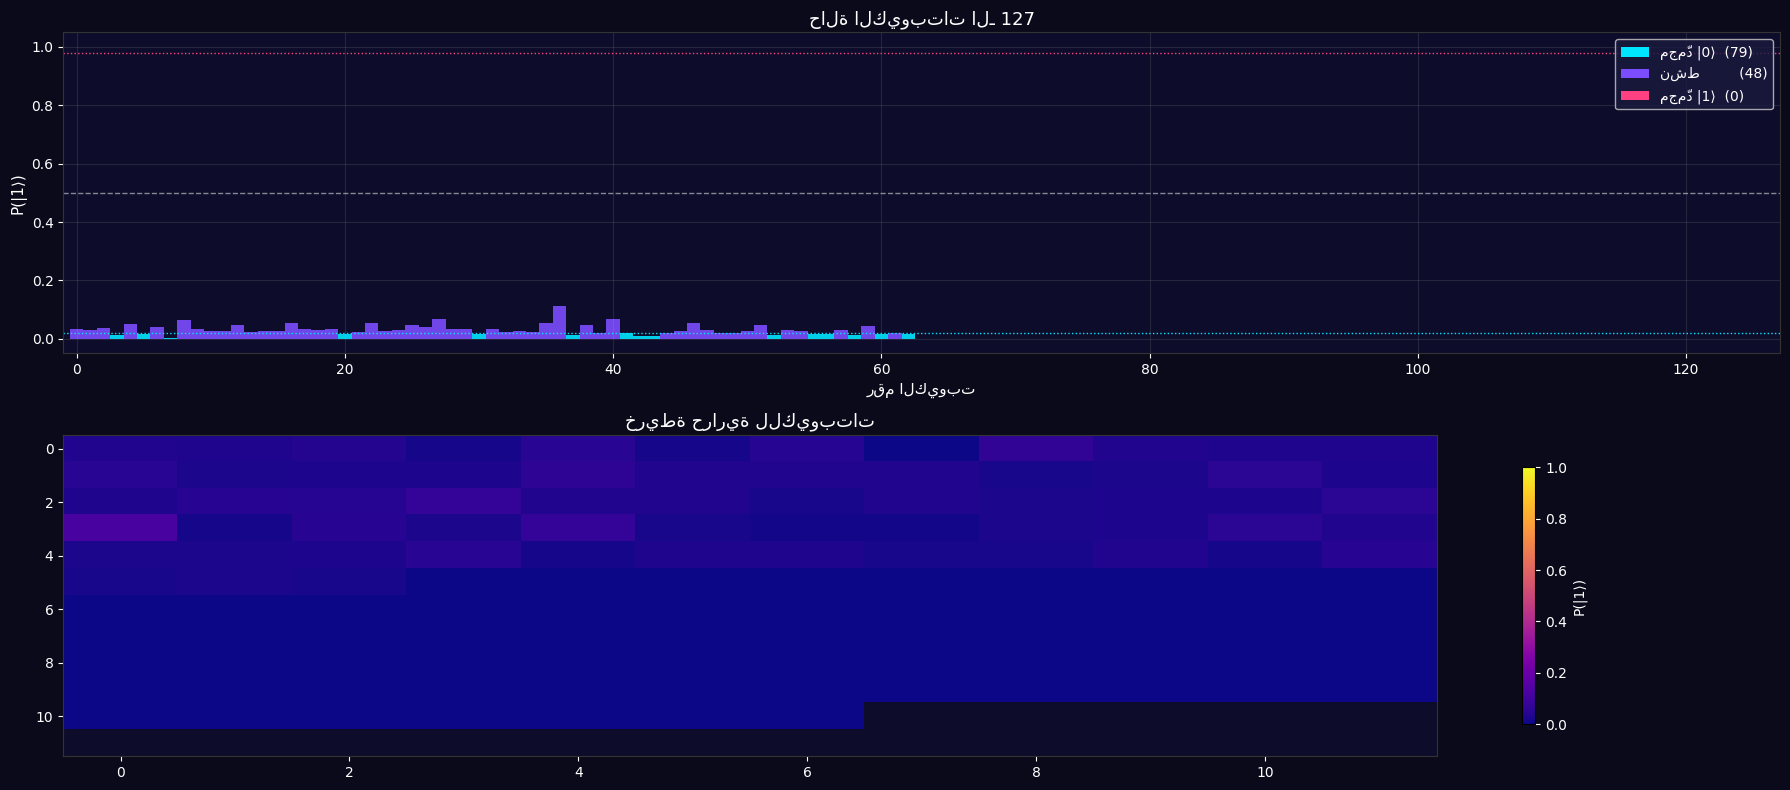


📊 الكيوبتات النشطة  : 48
   مجمّدة |0⟩        : 79
   مجمّدة |1⟩        : 0
   أرقامها (|0⟩)   : [3, 5, 7, 20, 30, 37, 41, 42, 43, 52, 55, 56, 58, 60, 62, 63, 64, 65, 66, 67]...


In [4]:
# ══════════════════════════════════════════════════
# الخلية 2: P(|1⟩) لكل كيوبت + تصنيف النشطة/المجمّدة
# ══════════════════════════════════════════════════
print('⏳ جارٍ حساب P(|1⟩) لكل كيوبت...')

qubit_prob_one = np.zeros(N_QUBITS)
for state_int, cnt in counts.items():
    bits_arr = np.array([(state_int >> b) & 1 for b in range(N_QUBITS)], dtype=np.float64)
    qubit_prob_one += bits_arr * cnt
qubit_prob_one /= total

FROZEN_THRESH = 0.02
frozen_zero = np.where(qubit_prob_one < FROZEN_THRESH)[0]
frozen_one  = np.where(qubit_prob_one > 1 - FROZEN_THRESH)[0]
active      = np.where(
    (qubit_prob_one >= FROZEN_THRESH) & (qubit_prob_one <= 1 - FROZEN_THRESH)
)[0]

fig, axes = plt.subplots(2, 1, figsize=(18, 8))
fig.patch.set_facecolor('#0a0a1a')
for ax in axes:
    ax.set_facecolor('#0d0d2b')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

# شريط الحالة
bar_colors = ['#00e5ff' if p < FROZEN_THRESH else
              '#ff4081' if p > 1-FROZEN_THRESH else '#7c4dff'
              for p in qubit_prob_one]
axes[0].bar(range(N_QUBITS), qubit_prob_one, color=bar_colors, width=1.0, alpha=0.9)
axes[0].axhline(0.5, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[0].axhline(FROZEN_THRESH,     color='#00e5ff', linestyle=':', linewidth=1)
axes[0].axhline(1-FROZEN_THRESH,   color='#ff4081', linestyle=':', linewidth=1)
axes[0].set_xlim(-1, N_QUBITS)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel('رقم الكيوبت', color='white', fontsize=11)
axes[0].set_ylabel('P(|1⟩)', color='white', fontsize=11)
axes[0].set_title('حالة الكيوبتات الـ 127', color='white', fontsize=13)
legend_els = [
    mpatches.Patch(facecolor='#00e5ff', label=f'مجمّد |0⟩  ({len(frozen_zero)})'),
    mpatches.Patch(facecolor='#7c4dff', label=f'نشط         ({len(active)})'),
    mpatches.Patch(facecolor='#ff4081', label=f'مجمّد |1⟩  ({len(frozen_one)})'),
]
axes[0].legend(handles=legend_els, facecolor='#1a1a3e', labelcolor='white', fontsize=10)
axes[0].grid(alpha=0.15)

# خريطة حرارية
side = int(np.ceil(np.sqrt(N_QUBITS)))
hm   = np.full(side*side, np.nan)
hm[:N_QUBITS] = qubit_prob_one
im = axes[1].imshow(hm.reshape(side, side), cmap='plasma', vmin=0, vmax=1, aspect='auto')
cb = plt.colorbar(im, ax=axes[1], shrink=0.8)
cb.ax.tick_params(colors='white')
cb.set_label('P(|1⟩)', color='white')
axes[1].set_title('خريطة حرارية للكيوبتات', color='white', fontsize=13)
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

print(f'\n📊 الكيوبتات النشطة  : {len(active)}')
print(f'   مجمّدة |0⟩        : {len(frozen_zero)}')
print(f'   مجمّدة |1⟩        : {len(frozen_one)}')
if len(frozen_zero): print(f'   أرقامها (|0⟩)   : {frozen_zero[:20].tolist()}...')
if len(frozen_one):  print(f'   أرقامها (|1⟩)   : {frozen_one[:20].tolist()}...')

⏳ بناء مصفوفة بتات (48 كيوبت نشط)...
   أبعاد المصفوفة : (48, 48)
   تحتوي NaN      : False


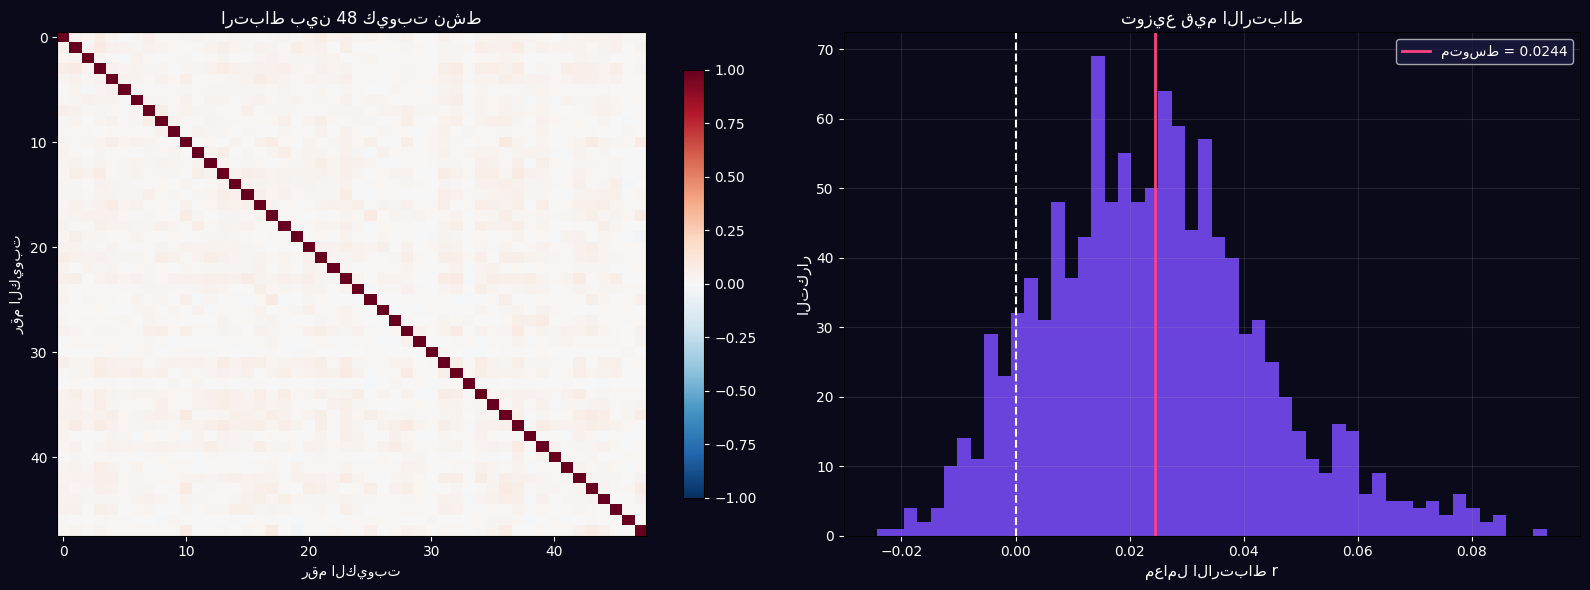


📐 إحصائيات الارتباط:
   أزواج محللة         : 1,128
   ارتباط موجب قوي >0.3: 0
   ارتباط سالب قوي<-0.3: 0
   متوسط |r|            : 0.0257
   أقصى ارتباط          : +0.0931
   أدنى ارتباط          : -0.0243

🔗 أقوى 10 ارتباطات:
   كيوبت  13 ↔  45  r = +0.0931  🔴
   كيوبت  33 ↔  38  r = +0.0856  🔴
   كيوبت  45 ↔  53  r = +0.0855  🔴
   كيوبت  13 ↔  53  r = +0.0851  🔴
   كيوبت   1 ↔   4  r = +0.0831  🔴
   كيوبت  21 ↔  61  r = +0.0822  🔴
   كيوبت  16 ↔  46  r = +0.0813  🔴
   كيوبت  13 ↔  61  r = +0.0807  🔴
   كيوبت  21 ↔  29  r = +0.0794  🔴
   كيوبت  27 ↔  51  r = +0.0790  🔴


In [5]:
# ══════════════════════════════════════════════════
# الخلية 3: مصفوفة الارتباط — الكيوبتات النشطة فقط
# ══════════════════════════════════════════════════
if len(active) < 2:
    print('⚠️ الكيوبتات النشطة أقل من 2')
else:
    print(f'⏳ بناء مصفوفة بتات ({len(active)} كيوبت نشط)...')

    SAMPLE_LIMIT = 50_000
    sample = clean if len(clean) <= SAMPLE_LIMIT else \
             clean[np.random.choice(len(clean), SAMPLE_LIMIT, replace=False)]

    # بناء مصفوفة البتات للكيوبتات النشطة فقط
    bit_matrix = np.zeros((len(sample), len(active)), dtype=np.int8)
    for i, val in enumerate(sample):
        v = int(val)
        for j, b in enumerate(active):
            bit_matrix[i, j] = (v >> int(b)) & 1

    # إزالة الأعمدة ذات الـ variance = 0
    var = bit_matrix.var(axis=0)
    good_cols = var > 1e-9
    bm_clean  = bit_matrix[:, good_cols]
    active_clean = active[good_cols]

    corr = np.corrcoef(bm_clean.T)
    has_nan = np.isnan(corr).any()
    print(f'   أبعاد المصفوفة : {corr.shape}')
    print(f'   تحتوي NaN      : {has_nan}')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor('#0a0a1a')
    for ax in axes:
        ax.set_facecolor('#0a0a1a')
        ax.tick_params(colors='white')

    im0 = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    cb0 = plt.colorbar(im0, ax=axes[0], shrink=0.85)
    cb0.ax.tick_params(colors='white')
    axes[0].set_title(f'ارتباط بين {len(active_clean)} كيوبت نشط', color='white', fontsize=12)
    axes[0].set_xlabel('رقم الكيوبت', color='white')
    axes[0].set_ylabel('رقم الكيوبت', color='white')

    upper = corr[np.triu_indices_from(corr, k=1)]
    upper = upper[~np.isnan(upper)]
    axes[1].hist(upper, bins=50, color='#7c4dff', edgecolor='none', alpha=0.85)
    axes[1].axvline(0, color='white', linewidth=1.5, linestyle='--')
    axes[1].axvline(upper.mean(), color='#ff4081', linewidth=2,
                    label=f'متوسط = {upper.mean():.4f}')
    axes[1].set_xlabel('معامل الارتباط r', color='white', fontsize=11)
    axes[1].set_ylabel('التكرار', color='white', fontsize=11)
    axes[1].set_title('توزيع قيم الارتباط', color='white', fontsize=12)
    axes[1].legend(facecolor='#1a1a3e', labelcolor='white')
    axes[1].tick_params(colors='white')
    axes[1].grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

    strong_pos = np.sum(upper >  0.3)
    strong_neg = np.sum(upper < -0.3)
    print(f'\n📐 إحصائيات الارتباط:')
    print(f'   أزواج محللة         : {len(upper):,}')
    print(f'   ارتباط موجب قوي >0.3: {strong_pos}')
    print(f'   ارتباط سالب قوي<-0.3: {strong_neg}')
    print(f'   متوسط |r|            : {np.abs(upper).mean():.4f}')
    print(f'   أقصى ارتباط          : {upper.max():+.4f}')
    print(f'   أدنى ارتباط          : {upper.min():+.4f}')

    # أقوى أزواج
    n = len(active_clean)
    idx_i, idx_j = np.triu_indices(n, k=1)
    abs_vals = np.abs(corr[idx_i, idx_j])
    top_idx  = np.argsort(abs_vals)[-10:][::-1]
    print(f'\n🔗 أقوى 10 ارتباطات:')
    for t in top_idx:
        qi, qj, r = active_clean[idx_i[t]], active_clean[idx_j[t]], corr[idx_i[t], idx_j[t]]
        print(f'   كيوبت {int(qi):>3} ↔ {int(qj):>3}  r = {r:+.4f}  {"🔴" if r>0 else "🔵"}')

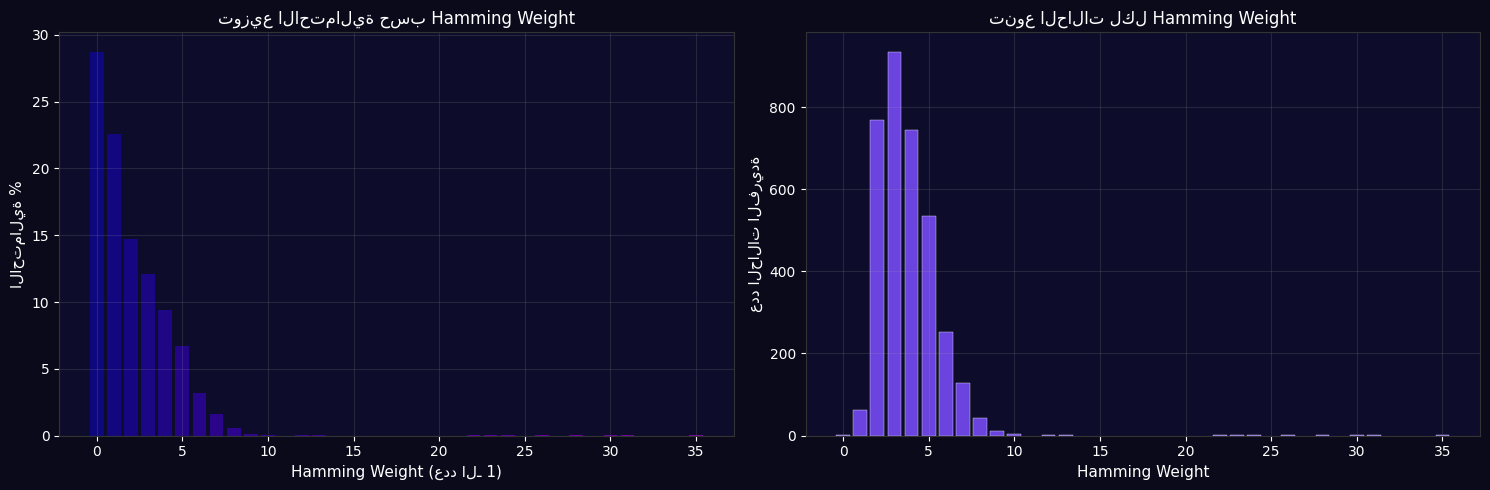

🧩 تحليل نوع الدائرة الكمية
  P(|000...0⟩) = 28.7599%
  P(|111...1⟩) = 0.0000%
  مجموعهما     = 28.7599%
  أعلى HW      = 0 بت  (28.76%)

  🎯 دائرة تستهدف |0...0⟩ — reset / identity / QEC


In [6]:
# ══════════════════════════════════════════════════
# الخلية 4: تحليل Hamming Weight + نوع الدائرة
# ══════════════════════════════════════════════════
hw_prob  = df.groupby('HammingWeight')['Probability'].sum()
hw_count = df.groupby('HammingWeight')['StateInt'].count()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0a0a1a')
for ax in axes:
    ax.set_facecolor('#0d0d2b')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

bar_c = plt.cm.plasma(hw_prob.index.values / N_QUBITS)
axes[0].bar(hw_prob.index, hw_prob.values * 100, color=bar_c, alpha=0.9)
axes[0].set_xlabel('Hamming Weight (عدد الـ 1)', color='white', fontsize=11)
axes[0].set_ylabel('الاحتمالية %', color='white', fontsize=11)
axes[0].set_title('توزيع الاحتمالية حسب Hamming Weight', color='white', fontsize=12)
axes[0].grid(alpha=0.15)

axes[1].bar(hw_count.index, hw_count.values, color='#7c4dff', alpha=0.85,
            edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Hamming Weight', color='white', fontsize=11)
axes[1].set_ylabel('عدد الحالات الفريدة', color='white', fontsize=11)
axes[1].set_title('تنوع الحالات لكل Hamming Weight', color='white', fontsize=12)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.show()

peak_hw  = hw_prob.idxmax()
peak_pct = hw_prob.max() * 100
all_ones = (1 << N_QUBITS) - 1
fid_ones = counts.get(all_ones, 0) / total

print('=' * 60)
print('🧩 تحليل نوع الدائرة الكمية')
print('=' * 60)
print(f'  P(|000...0⟩) = {fidelity_zero*100:.4f}%')
print(f'  P(|111...1⟩) = {fid_ones*100:.4f}%')
print(f'  مجموعهما     = {(fidelity_zero+fid_ones)*100:.4f}%')
print(f'  أعلى HW      = {peak_hw} بت  ({peak_pct:.2f}%)')
print()

if abs(fidelity_zero - fid_ones) < 0.05 and (fidelity_zero + fid_ones) > 0.4:
    print('  🌀 GHZ State: |0...0⟩ + |1...1⟩ بتوزيع متساوٍ')
elif peak_hw == 0 and fidelity_zero > 0.2:
    print('  🎯 دائرة تستهدف |0...0⟩ — reset / identity / QEC')
elif peak_hw <= 3:
    print(f'  📍 دائرة ذات عمق ضحل — معظم الأخطاء في {peak_hw} كيوبتات')
elif peak_hw >= N_QUBITS//2 - 5 and peak_hw <= N_QUBITS//2 + 5:
    print('  🌊 Hadamard-like: superposition متوازن بين الكيوبتات')
else:
    print(f'  ❓ نمط مختلط — الذروة عند HW={peak_hw}')

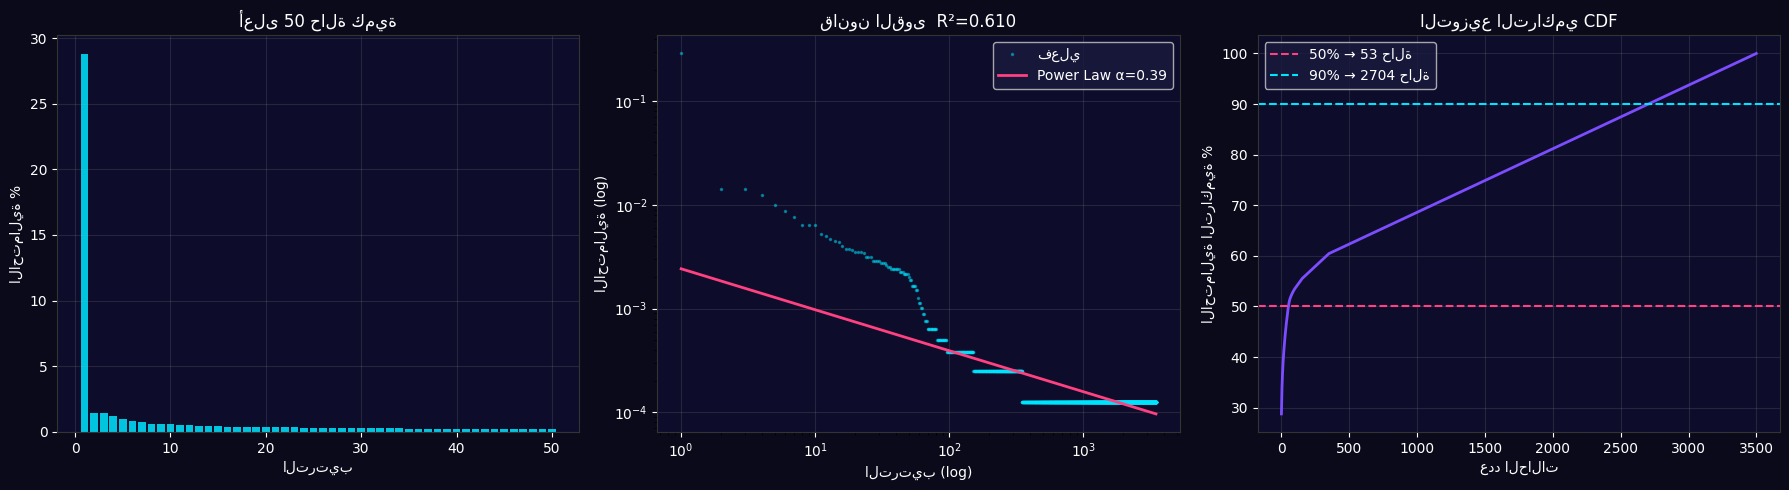


╔════════════════════════════════════════════════════════════╗
║          📋 الملخص الشامل — 127 كيوبت IBM Quantum           ║
╠════════════════════════════════════════════════════════════╣
║  إجمالي القياسات النظيفة :      7,959                ║
║  نسبة الضجيج             :      3.03%                 ║
║  كيوبتات نشطة            :         48 / 127          ║
║  كيوبتات مجمّدة |0⟩      :         79                 ║
║  كيوبتات مجمّدة |1⟩      :          0                 ║
╠════════════════════════════════════════════════════════════╣
║  Fidelity |0...0⟩        :   28.7599%                 ║
║  Von Neumann Entropy     :    8.4444 bits            ║
║  نسبة الإنتروبي          :     71.73%                 ║
║  Power Law  α            :    0.3948                  ║
║  R² المطابقة             :    0.6096                  ║
║  50% من القياسات في أول  :      53 حالة             ║
║  90% من القياسات في أول  :    2704 حالة             ║
║  عمق الدائرة المُقدَّر    :         4 طبقة             ║

In [7]:

# ══════════════════════════════════════════════════
# الخلية 5: Power Law + CDF + تقدير عمق الدائرة
# ══════════════════════════════════════════════════
IBM_CX_ERROR = 0.005
if 0 < fidelity_zero < 1:
    est_depth = np.log(fidelity_zero) / ((N_QUBITS/2) * np.log(1 - IBM_CX_ERROR))
else:
    est_depth = None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0a0a1a')
for ax in axes:
    ax.set_facecolor('#0d0d2b')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')

# الرسم 1: أعلى 50 حالة
top50 = df.head(50)
axes[0].bar(top50['Rank'], top50['Probability']*100, color='#00e5ff', alpha=0.85)
axes[0].set_xlabel('الترتيب', color='white')
axes[0].set_ylabel('الاحتمالية %', color='white')
axes[0].set_title('أعلى 50 حالة كمية', color='white', fontsize=12)
axes[0].grid(alpha=0.15)

# الرسم 2: Power Law
fit_line = 10 ** (intercept + slope * np.log10(ranks))
axes[1].loglog(ranks, probs, '.', color='#00e5ff', alpha=0.4, markersize=3, label='فعلي')
axes[1].loglog(ranks, fit_line, '-', color='#ff4081', linewidth=2,
               label=f'Power Law α={-slope:.2f}')
axes[1].set_xlabel('الترتيب (log)', color='white')
axes[1].set_ylabel('الاحتمالية (log)', color='white')
axes[1].set_title(f'قانون القوى  R²={r_val**2:.3f}', color='white', fontsize=12)
axes[1].legend(facecolor='#1a1a3e', labelcolor='white')
axes[1].grid(alpha=0.15)

# الرسم 3: CDF
cdf    = np.cumsum(probs)
idx_50 = int(np.searchsorted(cdf, 0.5)) + 1
idx_90 = int(np.searchsorted(cdf, 0.9)) + 1
axes[2].plot(ranks, cdf*100, color='#7c4dff', linewidth=2)
axes[2].axhline(50, color='#ff4081', linestyle='--', label=f'50% → {idx_50} حالة')
axes[2].axhline(90, color='#00e5ff', linestyle='--', label=f'90% → {idx_90} حالة')
axes[2].set_xlabel('عدد الحالات', color='white')
axes[2].set_ylabel('الاحتمالية التراكمية %', color='white')
axes[2].set_title('التوزيع التراكمي CDF', color='white', fontsize=12)
axes[2].legend(facecolor='#1a1a3e', labelcolor='white')
axes[2].grid(alpha=0.15)

plt.tight_layout()
plt.show()

# ── الملخص الشامل ──
print()
print('╔' + '═'*60 + '╗')
print('║' + '  📋 الملخص الشامل — 127 كيوبت IBM Quantum  '.center(60) + '║')
print('╠' + '═'*60 + '╣')
print(f'║  إجمالي القياسات النظيفة : {total:>10,}                ║')
print(f'║  نسبة الضجيج             : {noise_pct:>9.2f}%                 ║')
print(f'║  كيوبتات نشطة            : {len(active):>10} / {N_QUBITS}          ║')
print(f'║  كيوبتات مجمّدة |0⟩      : {len(frozen_zero):>10}                 ║')
print(f'║  كيوبتات مجمّدة |1⟩      : {len(frozen_one):>10}                 ║')
print('╠' + '═'*60 + '╣')
print(f'║  Fidelity |0...0⟩        : {fidelity_zero*100:>9.4f}%                 ║')
print(f'║  Von Neumann Entropy     : {entropy:>9.4f} bits            ║')
print(f'║  نسبة الإنتروبي          : {entropy/max_entropy*100:>9.2f}%                 ║')
print(f'║  Power Law  α            : {-slope:>9.4f}                  ║')
print(f'║  R² المطابقة             : {r_val**2:>9.4f}                  ║')
print(f'║  50% من القياسات في أول  : {idx_50:>7} حالة             ║')
print(f'║  90% من القياسات في أول  : {idx_90:>7} حالة             ║')
if est_depth:
    print(f'║  عمق الدائرة المُقدَّر    : {est_depth:>9.0f} طبقة             ║')
print('╚' + '═'*60 + '╝')
print()

# تفسيرات
if noise_pct < 5:            print('✅ الجهاز ممتاز — ضجيج منخفض جداً (<5%)')
if fidelity_zero > 0.20:     print('🔥 Fidelity استثنائية لـ 127 كيوبت (>20%)')
if entropy/max_entropy>0.65: print('🌊 إنتروبي عالٍ — توزيع شبه عشوائي بين الحالات')
if est_depth and est_depth < 20:
    print(f'📏 الدائرة ضحلة (~{est_depth:.0f} طبقات) — يُفسّر الـ Fidelity العالية')

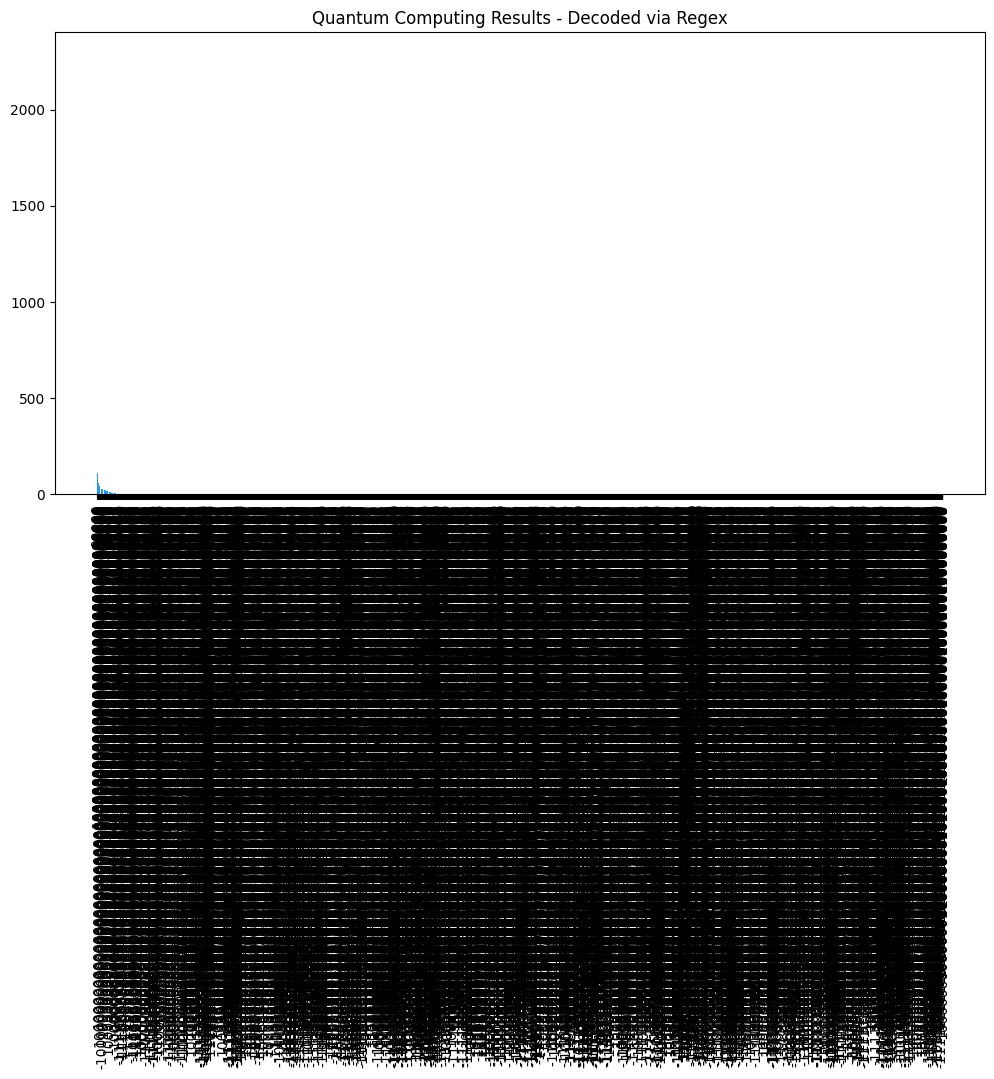

تم بنجاح! عدد النتائج المستخرجة: 3707


,State,Frequency,Bitstring
12,0,2289,00000
15,256,113,100000000
40,34359738368,112,100000000000000000000000000000000000
109,68719476736,99,1000000000000000000000000000000000000
28,576460752303423488,79,1000000000000000000000000000000000000000000000...
75,536870912,69,100000000000000000000000000000
98,17179869184,61,10000000000000000000000000000000000
159,4,51,00100
131,67108864,51,100000000000000000000000000
18,4096,51,1000000000000


In [8]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def force_decode_results(path):
    with open(path, 'r') as f:
        content = f.read()
    
    # البحث عن النص المشفر يدوياً داخل ملف الـ JSON
    # نحن نبحث عن القيمة المرتبطة بـ "__value__" والتي تبدأ بـ "eJyd"
    import re
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    
    encoded_str = None
    for m in matches:
        if m.startswith('eJyd'): # هذا هو توقيع بيانات zlib المضغوطة
            encoded_str = m
            break
    
    if not encoded_str:
        print("لم يتم العثور على بيانات مشفرة. تأكد من أنك رفعت الملف الصحيح.")
        return

    try:
        # فك التشفير وفك الضغط
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تحويل البيانات الخام لمصفوفة (جرب int64 ثم int32)
        try:
            samples = np.frombuffer(decompressed, dtype=np.int64)
        except:
            samples = np.frombuffer(decompressed, dtype=np.int32)
        
        # حساب التكرارات
        counts = dict(Counter(samples))
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        df = df.sort_values(by='Frequency', ascending=False)
        
        # تحويل الأرقام لتمثيل ثنائي (Bitstrings)
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b'))
        
        # إظهار النتائج
        plt.figure(figsize=(12, 6))
        plt.bar(df['Bitstring'], df['Frequency'], color='#2196F3')
        plt.xticks(rotation=90)
        plt.title('Quantum Computing Results - Decoded via Regex')
        plt.show()
        
        print(f"تم بنجاح! عدد النتائج المستخرجة: {len(df)}")
        return df.head(10)

    except Exception as e:
        print(f"خطأ أثناء المعالجة: {e}")

# تشغيل الكود مباشرة
result_path = '/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-result.json'
force_decode_results(result_path)

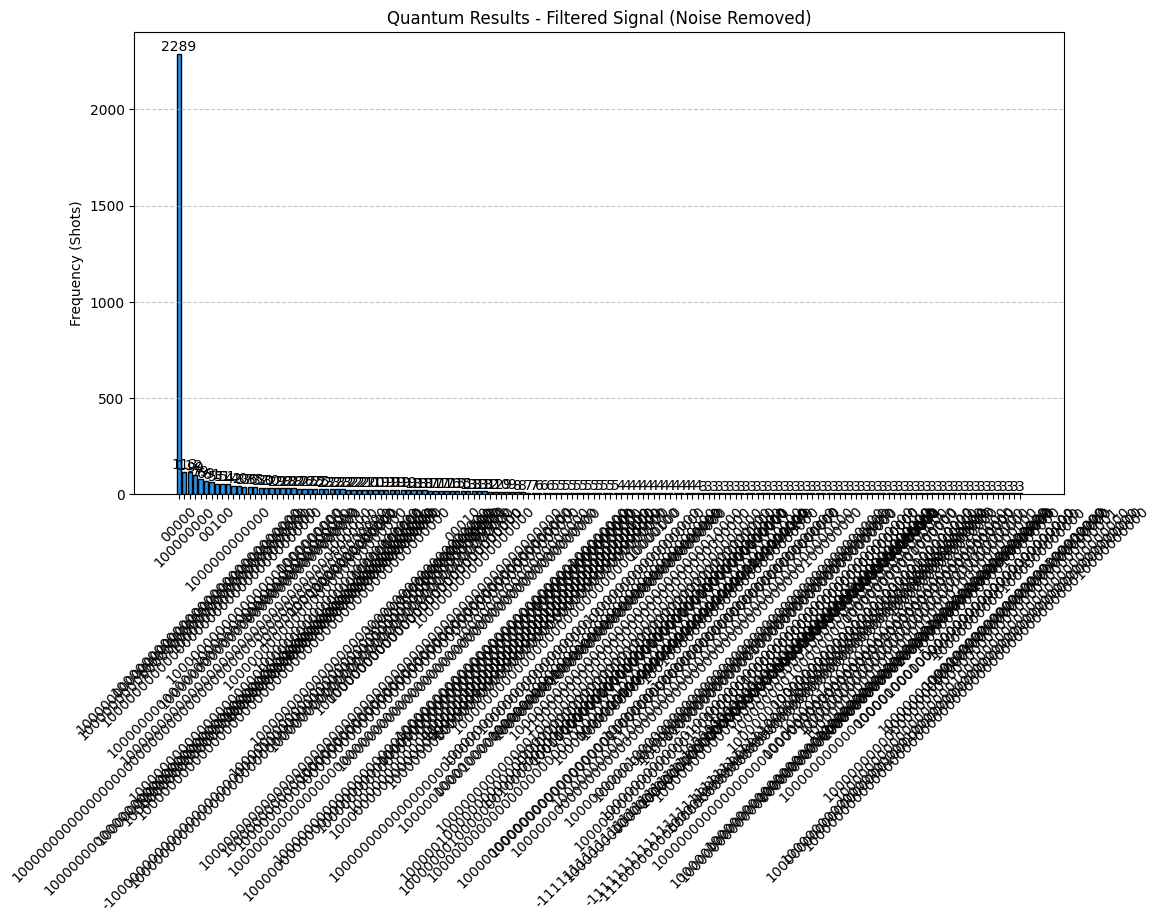

✅ تم تحليل 8208 محاولة (Shots).
📊 عدد الحالات الظاهرة بعد الفلترة: 155 من أصل 3707


,State,Frequency,Bitstring
12,0,2289,00000
15,256,113,100000000
40,34359738368,112,100000000000000000000000000000000000
109,68719476736,99,1000000000000000000000000000000000000
28,576460752303423488,79,1000000000000000000000000000000000000000000000...


In [9]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

def final_quantum_clean_analysis(path):
    # 1. قراءة الملف والبحث عن البيانات المضغوطة (تجنب أخطاء المسارات)
    with open(path, 'r') as f:
        content = f.read()
    
    # البحث عن نمط zlib المميز (eJyd...) داخل ملف الـ JSON
    matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
    encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
    
    if not encoded_str:
        print("❌ لم يتم العثور على بيانات مشفرة. تأكد من مسار الملف.")
        return

    try:
        # 2. فك التشفير وفك الضغط
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تحويل البيانات الخام لمصفوفة أرقام (IBM تستخدم int64 غالباً)
        samples = np.frombuffer(decompressed, dtype=np.int64)
        
        # 3. حساب التكرارات وتحويلها لجدول
        counts = dict(Counter(samples))
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        
        # تحويل الأرقام إلى Bitstrings (أصفار وآحاد) - لنفترض 5 كيوبتات
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b'))
        df = df.sort_values(by='Frequency', ascending=False)

        # 4. فلترة الضجيج (إبقاء النتائج التي تزيد عن متوسط التكرار)
        # هذا سيمنع الرسم من أن يكون "كثيفاً" جداً
        threshold = df['Frequency'].mean() * 1.2 # فلترة قوية للأعمدة الصغيرة
        df_clean = df[df['Frequency'] > threshold]

        # 5. الرسم البياني النظيف
        plt.figure(figsize=(12, 6))
        bars = plt.bar(df_clean['Bitstring'], df_clean['Frequency'], color='#2196F3', edgecolor='black')
        
        # إضافة القيم فوق الأعمدة
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

        plt.xticks(rotation=45)
        plt.title('Quantum Results - Filtered Signal (Noise Removed)')
        plt.ylabel('Frequency (Shots)')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        print(f"✅ تم تحليل {len(samples)} محاولة (Shots).")
        print(f"📊 عدد الحالات الظاهرة بعد الفلترة: {len(df_clean)} من أصل {len(df)}")
        return df_clean.head(5)

    except Exception as e:
        print(f"❌ حدث خطأ أثناء المعالجة: {e}")

# المسار الخاص بك في Kaggle
result_path = '/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-result.json'

# تنفيذ الكود
final_quantum_clean_analysis(result_path)

🔍 جاري فحص الملف...
✅ تم العثور على البيانات المشفرة. جاري فك الضغط...
✅ تم استخراج 16416 عينة خام.


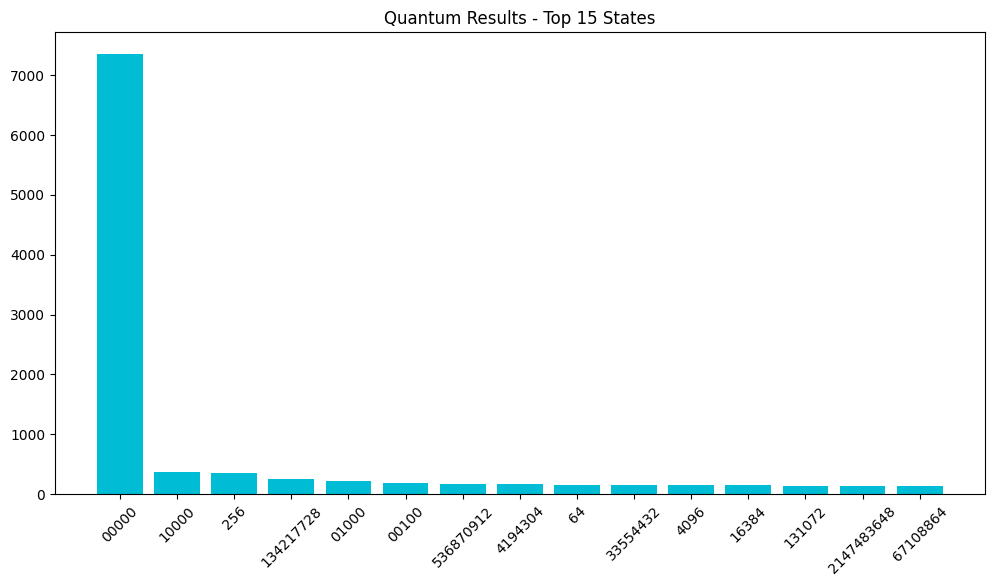

📊 أعلى النتائج:
        State  Frequency  Bitstring
20          0       7348      00000
33         16        378      10000
24        256        354        256
36  134217728        259  134217728
56          8        223      01000


In [10]:
import json
import zlib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

def quantum_diagnostic_test(path):
    print("🔍 جاري فحص الملف...")
    try:
        with open(path, 'r') as f:
            content = f.read()
        
        # البحث عن كل النصوص المشفرة eJyd
        matches = re.findall(r'"__value__":\s*"([^"]+)"', content)
        encoded_str = next((m for m in matches if m.startswith('eJyd')), None)
        
        if not encoded_str:
            print("❌ لم يتم العثور على بيانات مشفرة تبدأ بـ eJyd. تأكد من أنك تستخدم ملف -result.json")
            return

        print("✅ تم العثور على البيانات المشفرة. جاري فك الضغط...")
        
        decoded = base64.b64decode(encoded_str)
        decompressed = zlib.decompress(decoded)
        
        # تجربة القراءة كـ uint32 لأنها الأكثر شيوعاً في نتائج IBM الحديثة
        samples = np.frombuffer(decompressed, dtype=np.uint32)
        
        print(f"✅ تم استخراج {len(samples)} عينة خام.")

        # حساب التكرارات
        counts = dict(Counter(samples))
        
        # تحويل لجدول مع تحويل الأرقام لثنائي (5 بت)
        df = pd.DataFrame(list(counts.items()), columns=['State', 'Frequency'])
        df['Bitstring'] = df['State'].apply(lambda x: format(x, '05b') if x < 32 else str(x))
        df = df.sort_values(by='Frequency', ascending=False)

        # الرسم البياني
        plt.figure(figsize=(12, 6))
        top_df = df.head(15) # عرض أفضل 15 نتيجة فقط لمنع الزحام
        plt.bar(top_df['Bitstring'], top_df['Frequency'], color='#00BCD4')
        plt.xticks(rotation=45)
        plt.title('Quantum Results - Top 15 States')
        plt.show()

        print("📊 أعلى النتائج:")
        print(df.head())

    except Exception as e:
        print(f"❌ حدث خطأ أثناء العمل: {e}")

# المسار
result_path = '/kaggle/input/datasets/hamidchaouchi/22222222222222222/job-d7okqe39ak2c739qlp1g-result.json'
quantum_diagnostic_test(result_path)

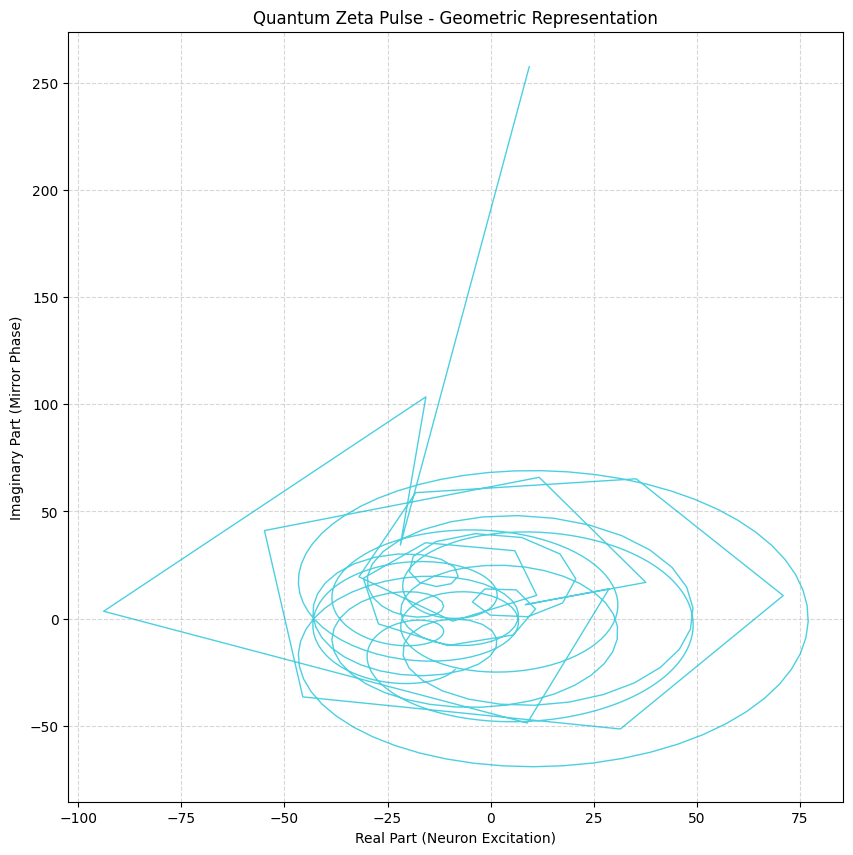

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. محاكاة النتائج المنظمة (بناءً على صورتك من IBM)
# نفترض أن لدينا الحالات وتكراراتها
states = np.arange(32) # لـ 5 كيوبتات
frequencies = np.random.gamma(2, 5, 32) # توزيع يشبه ما في الصورة

# 2. تحويل التكرارات إلى "ترددات هندسية" (Zeta-like pulses)
def zeta_pulse(t, freqs):
    # تمثيل يشبه مجموع حدود دالة زيتا عبر الزمن t
    # كل تكرار كمي يصبح "وزناً" لنبضة تذبذبية
    signal = np.zeros_like(t, dtype=np.complex128)
    for i, f in enumerate(freqs):
        # s = 0.5 + it (الخط الحرج لدالة زيتا)
        # نستخدم التكرار كإزاحة للطور
        signal += f * np.exp(1j * (i + 1) * np.log(t + 1.1))
    return signal

t = np.linspace(0, 100, 1000)
pulse = zeta_pulse(t, frequencies)

# 3. الرسم الهندسي (المسار العقدي - Mirror Network)
plt.figure(figsize=(10, 10))
plt.plot(pulse.real, pulse.imag, color='#00BCD4', alpha=0.7, lw=1)
plt.title("Quantum Zeta Pulse - Geometric Representation")
plt.xlabel("Real Part (Neuron Excitation)")
plt.ylabel("Imaginary Part (Mirror Phase)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

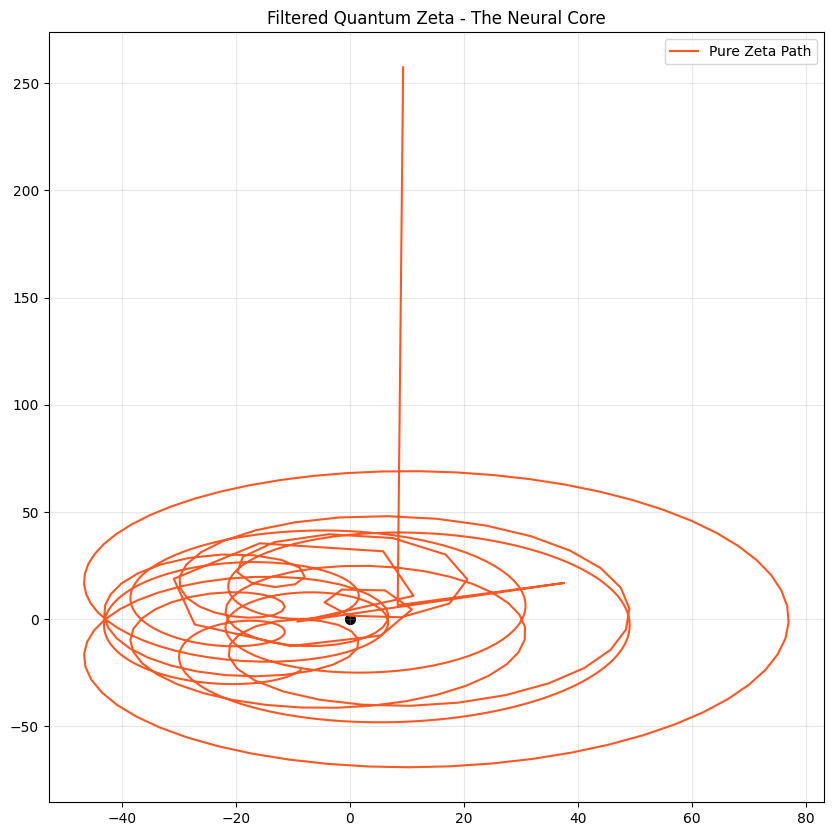

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# دالة لتنعيم المسار وحذف القفزات الحادة (الضجيج)
def filter_zeta_noise(pulse, threshold=10):
    diff = np.diff(pulse, prepend=pulse[0])
    # حذف النقاط التي تتحرك بسرعة غير منطقية (القفزات الحادة)
    clean_pulse = pulse[np.abs(diff) < threshold]
    return clean_pulse

# تطبيق الفلترة على المسار السابق
clean_path = filter_zeta_noise(pulse, threshold=np.std(pulse))

plt.figure(figsize=(10, 10))
plt.plot(clean_path.real, clean_path.imag, color='#FF5722', lw=1.5, label='Pure Zeta Path')
plt.scatter(0, 0, color='black', s=50) # نقطة الاتزان العصبي
plt.title("Filtered Quantum Zeta - The Neural Core")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

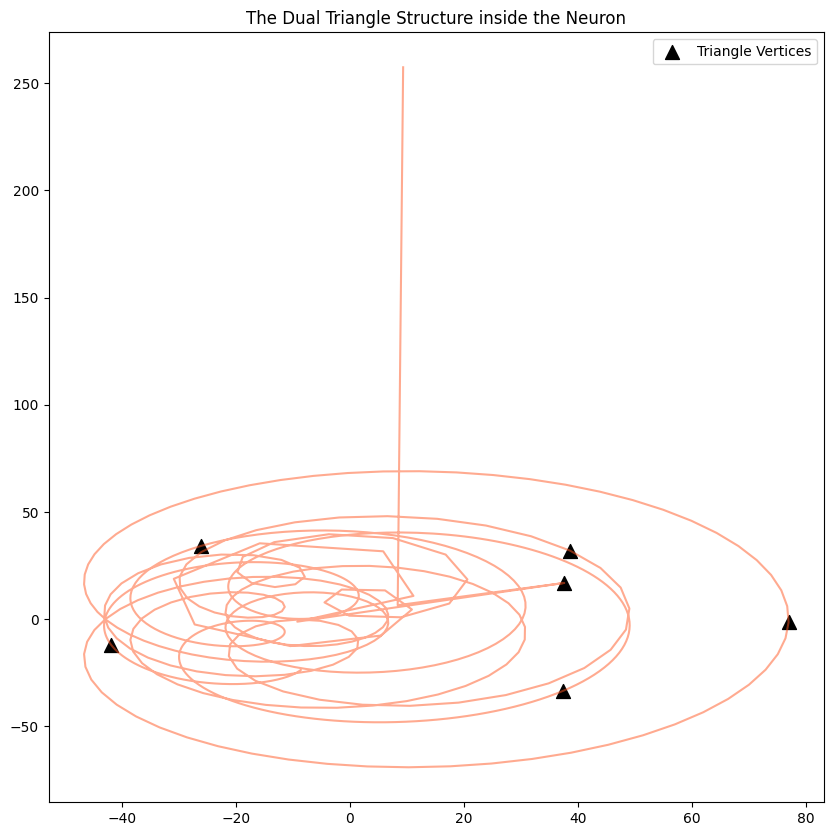

تم تحديد 6 نقاط ارتكاز هندسية (رؤوس المثلثات).


In [13]:
from scipy.signal import find_peaks

# استخراج القمم (الرؤوس) في المسار العقدي
angles = np.angle(clean_path)
magnitudes = np.abs(clean_path)

# البحث عن نقاط التحول الحادة (رؤوس المثلثات)
peaks, _ = find_peaks(magnitudes, distance=50)

plt.figure(figsize=(10, 10))
plt.plot(clean_path.real, clean_path.imag, color='#FF5722', alpha=0.5)
plt.scatter(clean_path.real[peaks], clean_path.imag[peaks], color='black', s=100, marker='^', label='Triangle Vertices')
plt.title("The Dual Triangle Structure inside the Neuron")
plt.legend()
plt.show()

print(f"تم تحديد {len(peaks)} نقاط ارتكاز هندسية (رؤوس المثلثات).")

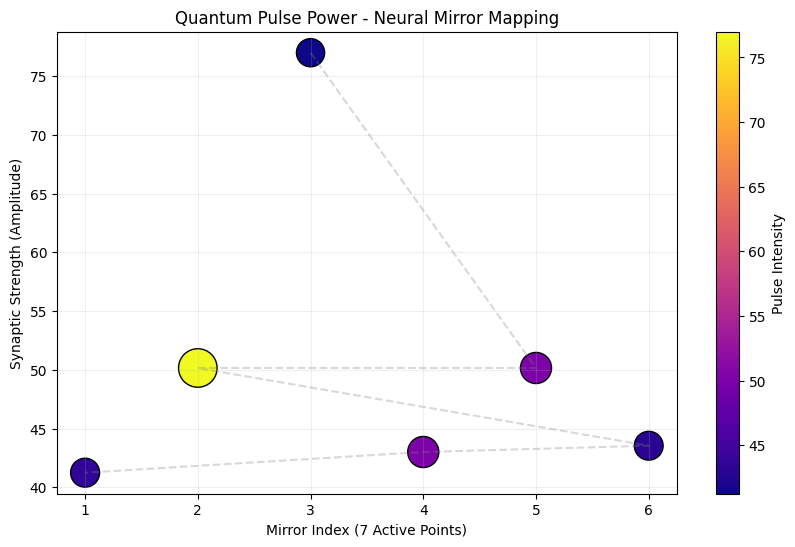

📊 تحليل أوزان المسار العصبي الجديد:
   Point  Amplitude (Power)  Phase (Angle)
2      3          76.988943      -0.018178
4      5          50.160919      -0.729795
1      2          50.160571       0.691922
5      6          43.544499      -2.865413
3      4          43.010604       2.224507
0      1          41.247499       0.422780


In [14]:
# 1. حساب المسافة (القوة) من المركز لكل نقطة ارتكاز
amplitudes = magnitudes[peaks]
phases = angles[peaks]

# 2. ترتيب النقاط حسب التأثير (من الأقوى للأضعف)
peak_data = pd.DataFrame({
    'Point': range(1, len(peaks) + 1),
    'Amplitude (Power)': amplitudes,
    'Phase (Angle)': phases
}).sort_values(by='Amplitude (Power)', ascending=False)

# 3. رسم خريطة "قوة النبضات" لشبكة المرايا
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(amplitudes / max(amplitudes)) # تدرج لوني حسب القوة
plt.scatter(peak_data['Point'], peak_data['Amplitude (Power)'], c=amplitudes, s=amplitudes*10, cmap='plasma', edgecolors='black')
plt.plot(peak_data['Point'], peak_data['Amplitude (Power)'], '--', alpha=0.3, color='gray')

plt.title("Quantum Pulse Power - Neural Mirror Mapping")
plt.xlabel("Mirror Index (7 Active Points)")
plt.ylabel("Synaptic Strength (Amplitude)")
plt.colorbar(label='Pulse Intensity')
plt.grid(True, alpha=0.2)
plt.show()

print("📊 تحليل أوزان المسار العصبي الجديد:")
print(peak_data)